In [1]:
# ============================================================
# MODULE 1 — Base Basics (Hand Static)
# Topics: Environment setup · Position estimation ·
#         Position control · Sensor tests
# Run from: notebooks/   (jupyter notebook)
# ============================================================

import importlib, sys

# Remove any cached env/utils modules from this session
to_remove = [key for key in sys.modules if key.startswith('env') or key.startswith('utils')]
for key in to_remove:
    del sys.modules[key]

print("Cache cleared:", to_remove)

Cache cleared: []


# Module 1 — Base Basics (Hand Static)
**Topics:** Environment setup · Position estimation · Position control · Sensor tests

Run each cell in order. A PyBullet window will open.

## 0. Imports

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pybullet as p
import time

from env.pybullet_env  import PyBulletEnv
from env.robot_loader  import RobotLoader
from env.obstacle_builder import ObstacleBuilder
from utils.controllers import OmniDriveController, BasePoseController
from utils.sensors     import UltrasonicSensor, CameraSensor, LiDARSensor
from utils.visualizer  import DebugVisualizer

print('Imports OK')

Imports OK


pybullet build time: Oct 21 2025 17:40:50


## 1. Start environment & load robot

In [3]:
env    = PyBulletEnv(gui=True)
env.start()

loader = RobotLoader()
loader.load()

# Keep arm static at home pose
HOME_Q = np.array([0.0, -0.4, 0.6])
loader.set_joint_positions(HOME_Q)
env.step_n(100)

pos, orn = loader.get_base_pose()
print(f'Base position    : {pos.round(4)}')
print(f'Base orientation : {np.array(orn).round(4)}')

Base position    : [ 1.000e-04 -0.000e+00  1.109e-01]
Base orientation : [-0.e+00 -2.e-04  0.e+00  1.e+00]


## 2. Position estimation — drive a square & log trajectory

In [ ]:
omni = OmniDriveController(loader)
viz  = DebugVisualizer()
traj = []

def drive_log(vx, vy, wz, steps):
    for _ in range(steps):
        omni.cmd_vel(vx, vy, wz)
        env.step()
        pos, _ = loader.get_base_pose()
        traj.append(pos[:2].copy())

# 1-metre square
N = 250
drive_log( 0.5,  0,   0, N)
drive_log( 0,    0.5, 0, N)
drive_log(-0.5,  0,   0, N)
drive_log( 0,   -0.5, 0, N)
omni.stop()

traj = np.array(traj)
print(f'Trajectory points: {len(traj)}')
print(f'Closure error    : {np.linalg.norm(traj[-1]-traj[0])*100:.1f} cm')

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ax.plot(traj[:,0], traj[:,1], 'b-', lw=1.5, label='Trajectory')
ax.plot(traj[0,0],  traj[0,1],  'go', ms=8, label='Start')
ax.plot(traj[-1,0], traj[-1,1], 'r*', ms=10, label='End')
ax.set_aspect('equal'); ax.grid(True, alpha=0.4)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('Base trajectory — square drive')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Position control — waypoint following

In [ ]:
# Better tuned controller
omni = OmniDriveController(loader)
ctrl = BasePoseController(
    omni,
    k_lin=1.5,          # stronger linear gain (was 1.2)
    k_ang=2.5,          # stronger angular gain (was 2.0)
    max_lin=0.5,        # faster max speed (was 0.4)
    max_ang=1.5,        # faster turning (was 1.2)
    goal_tol=0.06,      # 6 cm tolerance
    ang_tol=0.05,
)

waypoints = [(1.0, 0.0), (1.0, 1.0), (0.0, 1.0), (0.0, 0.0)]

for wx, wy in waypoints:
    print(f'  → ({wx}, {wy}) ...', end=' ')
    done = ctrl.drive_to(
        wx, wy,
        goal_yaw=0.0,
        env=env,
        timeout_steps=6000,     # doubled from 3000
    )
    pos, _ = loader.get_base_pose()
    err = np.linalg.norm(pos[:2] - np.array([wx, wy]))
    print(f'reached={done}  err={err*100:.1f} cm')

print('Waypoint sequence done')

## 4a. Ultrasonic sensor

In [4]:
# Place a wall 0.8 m ahead
wall_col = p.createCollisionShape(p.GEOM_BOX, halfExtents=[0.02,1.0,0.3])
wall_vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[0.02,1.0,0.3], rgbaColor=[0.6,0.6,0.6,1])
wall_id  = p.createMultiBody(0, wall_col, wall_vis, [0.8,0,0.3])
env.step_n(10)

us  = UltrasonicSensor(loader)
samples = [us.read().distances for _ in range(5) if not env.step_n(5) or True]

print('Ultrasonic readings (5 samples):')
for i, s in enumerate(samples):
    print(f'  [{i}] {s}')

p.removeBody(wall_id)

Ultrasonic readings (5 samples):
  [0] {'front': 0.5325735811747845, 'back': 2.998186050604646, 'left': 2.9938987254578047, 'right': 3.0}
  [1] {'front': 0.5293589555288514, 'back': 3.0, 'left': 2.9982406446600676, 'right': 2.9927648225427013}
  [2] {'front': 0.5263756853693639, 'back': 3.0, 'left': 3.0, 'right': 2.9962981357867493}
  [3] {'front': 0.5262262627646468, 'back': 2.9985718867153737, 'left': 2.994301940176767, 'right': 3.0}
  [4] {'front': 0.5312337073421244, 'back': 2.998251109965722, 'left': 3.0, 'right': 3.0}


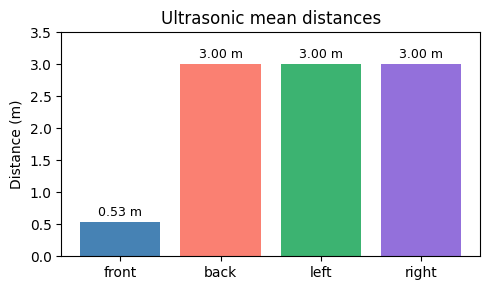

In [5]:
dirs  = ['front','back','left','right']
means = [np.mean([s[d] for s in samples]) for d in dirs]

fig, ax = plt.subplots(figsize=(5,3))
bars = ax.bar(dirs, means, color=['steelblue','salmon','mediumseagreen','mediumpurple'])
ax.set_ylabel('Distance (m)'); ax.set_title('Ultrasonic mean distances'); ax.set_ylim(0,3.5)
for bar,val in zip(bars,means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f} m', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

## 4b. Camera (RGB-D)

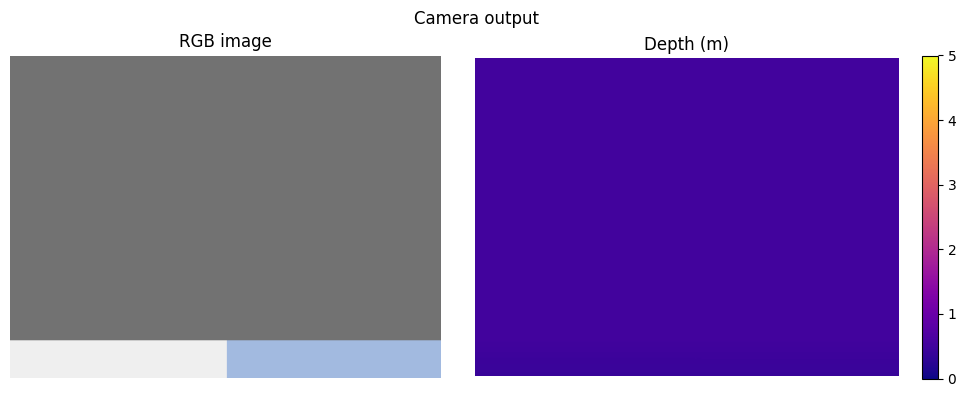

RGB (240, 320, 3)  depth min/max 0.40/0.52 m


In [6]:
# Place a wall 0.8 m ahead
wall_col = p.createCollisionShape(p.GEOM_BOX, halfExtents=[0.02,1.0,0.3])
wall_vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[0.02,1.0,0.3], rgbaColor=[0.6,0.6,0.6,1])
wall_id  = p.createMultiBody(0, wall_col, wall_vis, [0.8,0,0.3])
env.step_n(10)

cam   = CameraSensor(loader)
frame = cam.read()

fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].imshow(frame.rgb); axes[0].set_title('RGB image'); axes[0].axis('off')
dv = axes[1].imshow(frame.depth, cmap='plasma', vmin=0, vmax=5)
axes[1].set_title('Depth (m)'); plt.colorbar(dv, ax=axes[1], fraction=0.046); axes[1].axis('off')
plt.suptitle('Camera output'); plt.tight_layout(); plt.show()
print(f'RGB {frame.rgb.shape}  depth min/max {frame.depth.min():.2f}/{frame.depth.max():.2f} m')

p.removeBody(wall_id)

In [7]:
# Reset to origin
p.resetBasePositionAndOrientation(
    loader.base_id, [0,0,0.05], p.getQuaternionFromEuler([0,0,0]))
env.step_n(30)

omni = OmniDriveController(loader)


## 4c. LiDAR 360°

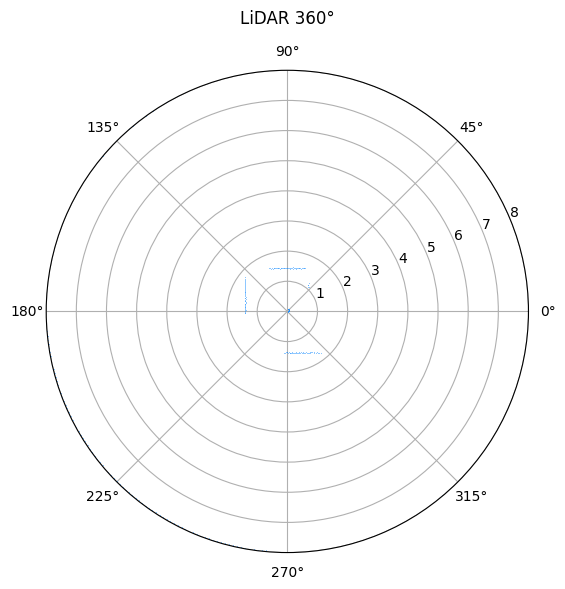

Rays: 360  min: 0.05 m  max: 8.00 m


In [8]:
obs = ObstacleBuilder(); obs.build_default_maze(); env.step_n(20)

lidar = LiDARSensor(loader)
scan  = lidar.read()

fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection':'polar'})
ax.plot(scan.angles, scan.distances, ',', color='dodgerblue', alpha=0.5, ms=1)
ax.set_title('LiDAR 360°', pad=15); ax.set_theta_zero_location('E')
ax.set_rmax(lidar.max_r); plt.tight_layout(); plt.show()
print(f'Rays: {len(scan.distances)}  min: {scan.distances.min():.2f} m  max: {scan.distances.max():.2f} m')

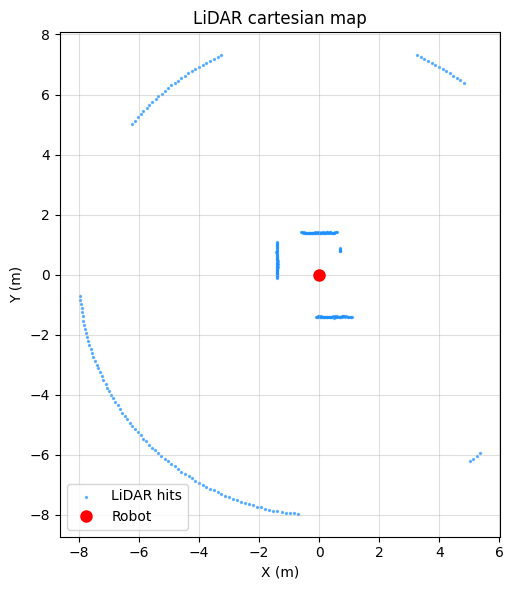

In [9]:
pos, _ = loader.get_base_pose()
xs = pos[0] + scan.distances * np.cos(scan.angles)
ys = pos[1] + scan.distances * np.sin(scan.angles)

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(xs, ys, s=2, c='dodgerblue', alpha=0.6, label='LiDAR hits')
ax.plot(*pos[:2], 'ro', ms=8, label='Robot')
ax.set_aspect('equal'); ax.grid(True, alpha=0.4)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('LiDAR cartesian map'); ax.legend(); plt.tight_layout(); plt.show()

## 5. Cleanup

In [ ]:
obs.clear(); viz.clear(); env.close()
print('Done.')